In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import time
import requests

In [40]:
df = pd.read_csv('ip_addresses.csv')

In [41]:
df.head()

,ip address,Latitude,Longitude,Timestamp,suspicious
0,173.198.105.40,35.3696,-119.0105,1736919120,0.0
1,5.165.146.0,56.1089,47.4821,1736919120,0.0
2,70.118.96.132,29.4227,-98.4927,1736919120,0.0
3,173.197.225.168,30.4264,-84.9462,1736919120,0.0
4,210.145.96.0,37.3170,140.3849,1736919120,0.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ip address  2940 non-null   object 
 1   Latitude    2940 non-null   float64
 2   Longitude   2940 non-null   float64
 3   Timestamp   2940 non-null   int64  
 4   suspicious  2940 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 115.0+ KB


<Axes: ylabel='Frequency'>

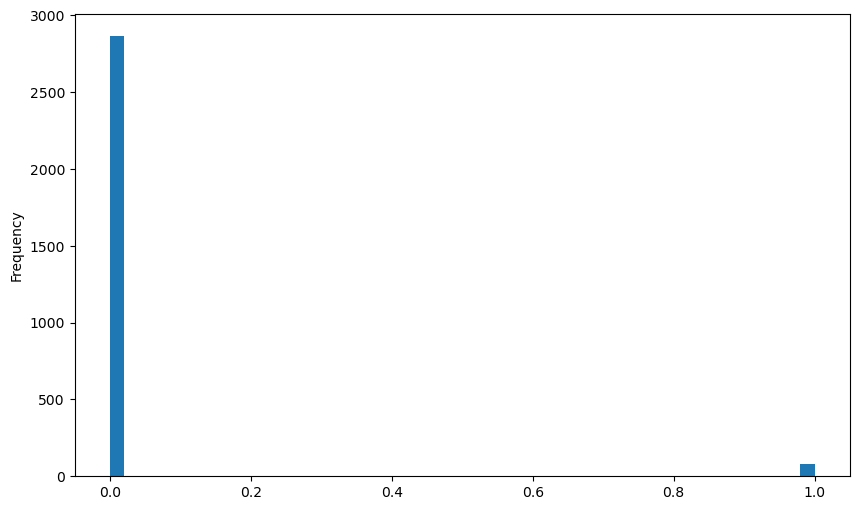

In [43]:
df['suspicious'].plot(kind='hist', bins=50, figsize=(10, 6))  

In [44]:
df['timestamp_col'] = pd.to_datetime(df['Timestamp'], unit='s')

df

,ip address,Latitude,Longitude,Timestamp,suspicious,timestamp_col
0,173.198.105.40,35.3696,-119.0105,1736919120,0.0,2025-01-15 05:32:00
1,5.165.146.0,56.1089,47.4821,1736919120,0.0,2025-01-15 05:32:00
2,70.118.96.132,29.4227,-98.4927,1736919120,0.0,2025-01-15 05:32:00
3,173.197.225.168,30.4264,-84.9462,1736919120,0.0,2025-01-15 05:32:00
4,210.145.96.0,37.3170,140.3849,1736919120,0.0,2025-01-15 05:32:00
...,...,...,...,...,...,...
2935,193.200.161.0,55.7386,37.6068,1736919720,0.0,2025-01-15 05:42:00
2936,188.162.146.0,45.0355,38.9750,1736919720,0.0,2025-01-15 05:42:00
2937,39.144.102.0,34.7732,113.7220,1736919720,0.0,2025-01-15 05:42:00
2938,39.144.99.0,35.0195,110.9848,1736919720,0.0,2025-01-15 05:42:00


In [45]:
df['timestamp_col'].min()

Timestamp('2025-01-15 05:32:00')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ip address     2940 non-null   object        
 1   Latitude       2940 non-null   float64       
 2   Longitude      2940 non-null   float64       
 3   Timestamp      2940 non-null   int64         
 4   suspicious     2940 non-null   float64       
 5   timestamp_col  2940 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 137.9+ KB


In [23]:
df['minutes'] = df['timestamp_col'].dt.minute

In [47]:
min_time = df['Timestamp'].min()    
df['time_diff'] = df['Timestamp'] - min_time

In [59]:
df.head(15)

,ip address,Latitude,Longitude,Timestamp,suspicious,timestamp_col,time_diff
0,173.198.105.40,35.3696,-119.0105,1736919120,0.0,2025-01-15 05:32:00,0
1,5.165.146.0,56.1089,47.4821,1736919120,0.0,2025-01-15 05:32:00,0
2,70.118.96.132,29.4227,-98.4927,1736919120,0.0,2025-01-15 05:32:00,0
3,173.197.225.168,30.4264,-84.9462,1736919120,0.0,2025-01-15 05:32:00,0
4,210.145.96.0,37.3170,140.3849,1736919120,0.0,2025-01-15 05:32:00,0
5,93.184.160.0,55.7386,37.6068,1736919120,0.0,2025-01-15 05:32:00,0
6,89.188.118.0,55.7386,37.6068,1736919121,0.0,2025-01-15 05:32:01,1
7,68.115.230.48,34.8950,-81.9204,1736919121,0.0,2025-01-15 05:32:01,1
8,95.32.224.0,55.7386,37.6068,1736919121,0.0,2025-01-15 05:32:01,1
9,185.89.8.0,55.7386,37.6068,1736919121,0.0,2025-01-15 05:32:01,1


In [87]:
df_grouped = df.groupby('time_diff')
df_grouped.ngroups


589

I need to make that program not need to depends on exact minutes. Like what I suppose to do is convert column 'timestamp_col'
to the minutes and then. No I just need the original column 'Timestamp' and then make a time like make another column


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ip address     2940 non-null   object        
 1   Latitude       2940 non-null   float64       
 2   Longitude      2940 non-null   float64       
 3   Timestamp      2940 non-null   int64         
 4   suspicious     2940 non-null   float64       
 5   timestamp_col  2940 non-null   datetime64[ns]
 6   time_diff      2940 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 160.9+ KB


In [81]:
df['ip address'].unique().shape

(2940,)

In [82]:
df.shape

(2940, 7)

In [64]:
def send_data(data):
    url = 'http://127.0.0.1:5000/receive'
    headers = {'Content-Type': 'application/json'}
    
    # Send POST request to the local receiver
    response = requests.post(url, data=data, headers=headers)
    
    return (response.status_code,response.text)

In [73]:

prev_sec = 0
for name, group_df in df_grouped:
    time.sleep(name- prev_sec)
    prev_sec = name
    code, text = send_data(group_df.to_json(orient='records'))
    print(code, text)

200 {"message":"Data received successfully!","status":"success"}

200 {"message":"Data received successfully!","status":"success"}

200 {"message":"Data received successfully!","status":"success"}

200 {"message":"Data received successfully!","status":"success"}



KeyboardInterrupt: 

In [26]:
json_string = df.to_json(orient='records')

AttributeError: 'DataFrame' object has no attribute 'load'